# Compare Global Views from Three TFRecord Files

This notebook loads three different TFRecord files and compares the global views from the first 10 examples in each dataset.


In [1]:
# %pip install --upgrade pip
# %pip install tensorflow
# import sys; print(sys.executable)  # sanity check: which Python the kernel is using
# import tensorflow as tf; print(tf.__version__)

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the three file paths
# files_april = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00005'
files_april = '/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00005'
# files_oct25 = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050'
# files_oct25 = '/pdo/astronet-data/data/tfrecords/oct2025_original/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/00000-of-00050'
files_oct25= '/pdo/astronet-data/data/tfrecords/oct2025_30minbin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050'
# files_oct25_cadencebin = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050-cadencebin'
files_oct25_cadencebin = '/pdo/astronet-data/data/tfrecords/oct2025_cadencebin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050'

# List of file paths and their labels
file_paths = [files_april, files_oct25_cadencebin, files_oct25]
file_labels = ['April', 'Oct25_CadenceBin', 'Oct25_30min']

print("File paths defined:")
for i, (path, label) in enumerate(zip(file_paths, file_labels)):
    print(f"{i+1}. {label}: {path}")


2025-10-28 18:13:23.179586: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-28 18:13:27.978906: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


File paths defined:
1. April: /pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00005
2. Oct25_CadenceBin: /pdo/astronet-data/data/tfrecords/oct2025_cadencebin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050
3. Oct25_30min: /pdo/astronet-data/data/tfrecords/oct2025_30minbin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050


In [29]:
import tensorflow as tf

def list_tfrecord_features(file_path, num_examples=1):
    """
    List all available feature names in a TFRecord file by inspecting one or a few examples.
    """
    raw_dataset = tf.data.TFRecordDataset([file_path])

    for i, raw_record in enumerate(raw_dataset.take(num_examples)):
        example = tf.train.Example()
        example.ParseFromString(raw_record.numpy())
        features = example.features.feature.keys()
        print(f"Example {i} has the following features:")
        for f in features:
            print(f"  - {f}")
        print("-" * 40)

# Example usage:
list_tfrecord_features("/pdo/astronet-data/data/tfrecords/oct2025_30minbin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050")

Example 0 has the following features:
  - local_view
  - local_aperture_l
  - local_scale_present
  - secondary_std
  - local_scale_present_0.3
  - local_std
  - global_view_double_period
  - star_mass_present
  - local_std_even
  - global_view_half_period_0.3
  - local_view_half_period_0.3
  - local_mask
  - secondary_view_0.3
  - global_view_double_period_mask_0.3
  - global_view_double_period_mask
  - local_aperture_m_0.3
  - global_view_0.3
  - astro_id
  - local_std_odd
  - local_view_odd
  - global_view_double_period_std_0.3
  - local_std_odd_0.3
  - local_aperture_l_5.0
  - global_view_half_period
  - star_rad
  - global_view_double_period_mask_5.0
  - secondary_scale_5.0
  - global_mask_5.0
  - local_mask_odd
  - global_view_half_period_std
  - local_mask_5.0
  - local_view_half_period_5.0
  - star_rad_est
  - local_view_half_period_std_5.0
  - global_view_half_period_5.0
  - secondary_view_5.0
  - local_view_odd_5.0
  - local_std_even_5.0
  - local_view_even_5.0
  - local_view

2025-10-28 18:27:29.426979: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


: 

In [23]:
import tensorflow as tf
import numpy as np

def load_tfrecord_examples(file_path, num_examples=20, verbose=False):
    """
    Load the first num_examples from a TFRecord file and extract global_view and astro_id.

    Args:
        file_path (str): Path to the TFRecord file
        num_examples (int): Number of examples to load
        verbose (bool): Whether to print feature keys for debugging

    Returns:
        (list, list): (global_views, astro_ids)
    """
    global_views = []
    astro_ids = []

    try:
        raw_dataset = tf.data.TFRecordDataset([file_path])

        for i, raw_record in enumerate(raw_dataset.take(num_examples)):
            example = tf.train.Example()
            example.ParseFromString(raw_record.numpy())

            features = example.features.feature
            if verbose:
                print(f"Example {i} features: {list(features.keys())}")

            # --- Extract global_view ---
            if "global_view" in features:
                global_view = np.array(features["global_view"].float_list.value)
                global_views.append(global_view)
            else:
                if verbose:
                    print(f"Warning: global_view not found in example {i}")
                global_views.append(None)

            # --- Extract astro_id ---
            if "astro_id" in features:
                astro_feature = features["astro_id"]
                if astro_feature.bytes_list.value:
                    astro_id = astro_feature.bytes_list.value[0].decode("utf-8")
                elif astro_feature.int64_list.value:
                    astro_id = str(astro_feature.int64_list.value[0])
                elif astro_feature.float_list.value:
                    astro_id = str(astro_feature.float_list.value[0])
                else:
                    astro_id = f"example_{i}"
                astro_ids.append(astro_id)
            else:
                astro_ids.append(f"example_{i}")

    except Exception as e:
        print(f"❌ Error loading {file_path}: {e}")
        return [], []

    print(f"✅ Loaded {len(global_views)} examples from {file_path}")
    return global_views, astro_ids

In [24]:
# Load data from all three files
all_global_views = []
all_astro_ids = []

print("Loading data from all three TFRecord files...")
for i, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    print(f"\nLoading {label} ({file_path})...")
    global_views, astro_ids = load_tfrecord_examples(file_path, num_examples=20)
    all_global_views.append(global_views)
    all_astro_ids.append(astro_ids)
    print(f"Loaded {len(global_views)} examples from {label}")

print(f"\nData loading complete!")
print(f"Total datasets: {len(all_global_views)}")
for i, (views, ids) in enumerate(zip(all_global_views, all_astro_ids)):
    print(f"Dataset {i+1} ({file_labels[i]}): {len(views)} examples")

print('List of astro_ids:')
print(all_astro_ids)

Loading data from all three TFRecord files...

Loading April (/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00005)...
✅ Loaded 20 examples from /pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00005
Loaded 20 examples from April

Loading Oct25_CadenceBin (/pdo/astronet-data/data/tfrecords/oct2025_cadencebin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050)...
✅ Loaded 20 examples from /pdo/astronet-data/data/tfrecords/oct2025_cadencebin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050
Loaded 20 examples from Oct25_CadenceBin

Loading Oct25_30min (/pdo/astronet-data/data/tfrecords/oct2025_30minbin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-test/00000-of-00050)...
✅ Loaded 20 examples from /pdo/astronet-data/data/tfrecords/oct2025_30minbin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-te

2025-10-28 18:24:46.411859: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2025-10-28 18:24:46.462689: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2025-10-28 18:24:46.503950: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{n

In [25]:
def plot_global_view_comparison(example_idx):
    """
    Plot global views from all three datasets for a specific example.

    Args:
        example_idx (int): Index of the example to plot (0-9)
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, (views, label) in enumerate(zip(all_global_views, file_labels)):
        if example_idx < len(views) and views[example_idx] is not None:
            axes[i].plot(views[example_idx], linewidth=1)
            axes[i].set_title(f'{label}\nAstro ID: {all_astro_ids[i][example_idx]}')
            axes[i].set_xlabel('Time Index')
            axes[i].set_ylabel('Flux')
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylim(-1.05, 0.3)
        else:
            axes[i].text(0.5, 0.5, f'No data available\nfor example {example_idx}',
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{label} - No Data')

    plt.suptitle(f'Global View Comparison - Example {example_idx + 1}', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Function defined to plot global view comparisons")


Function defined to plot global view comparisons


Generating comparison plots for all examples...

Plotting example 1...


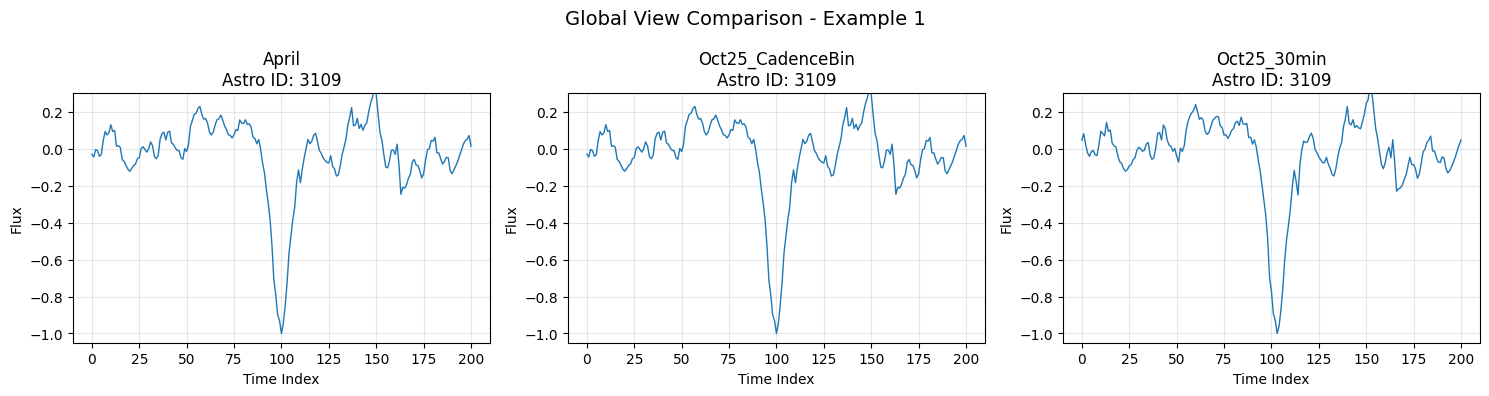


Plotting example 2...


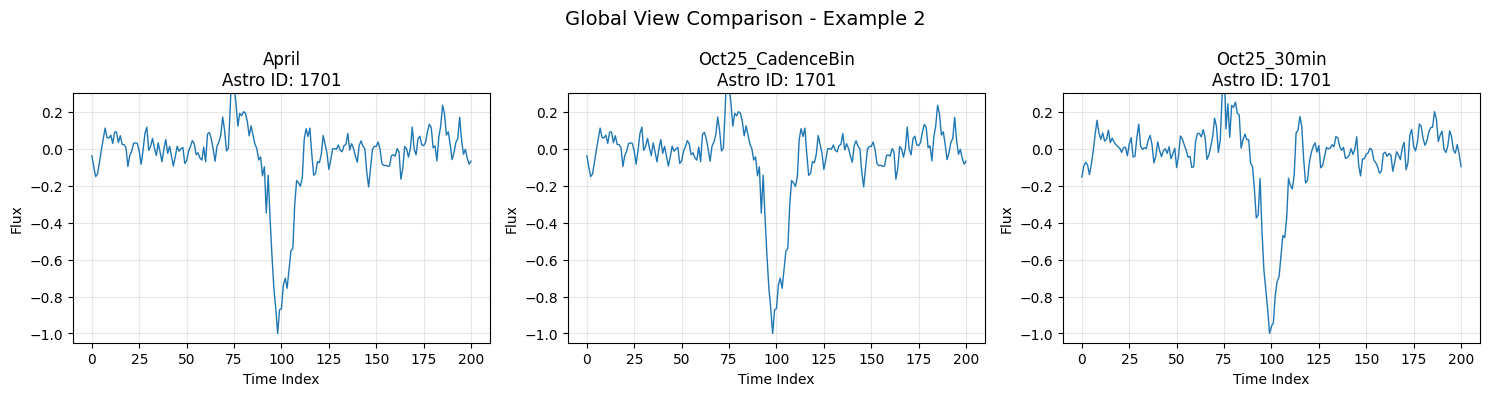


Plotting example 3...


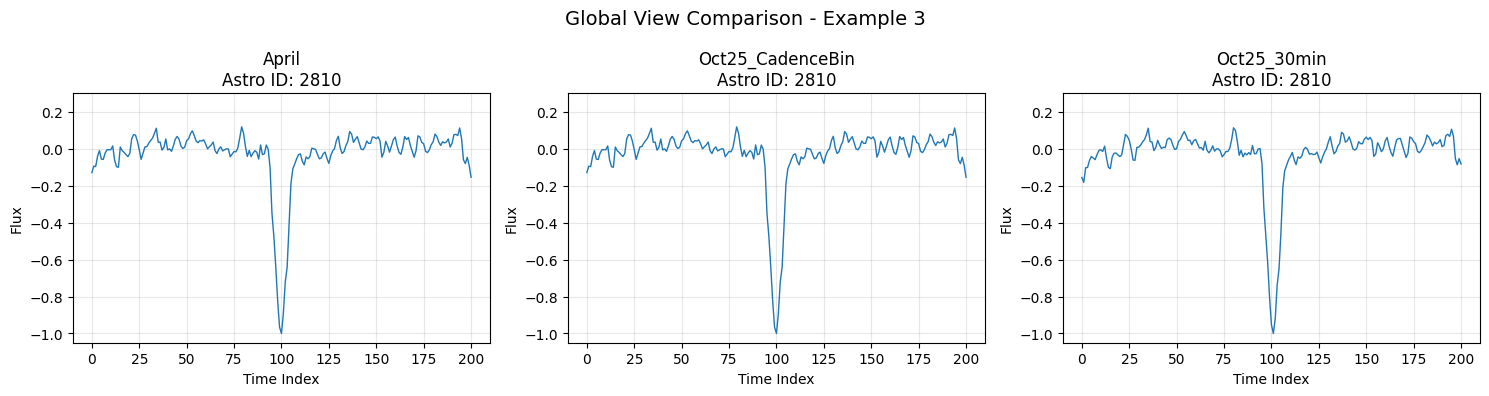


Plotting example 4...


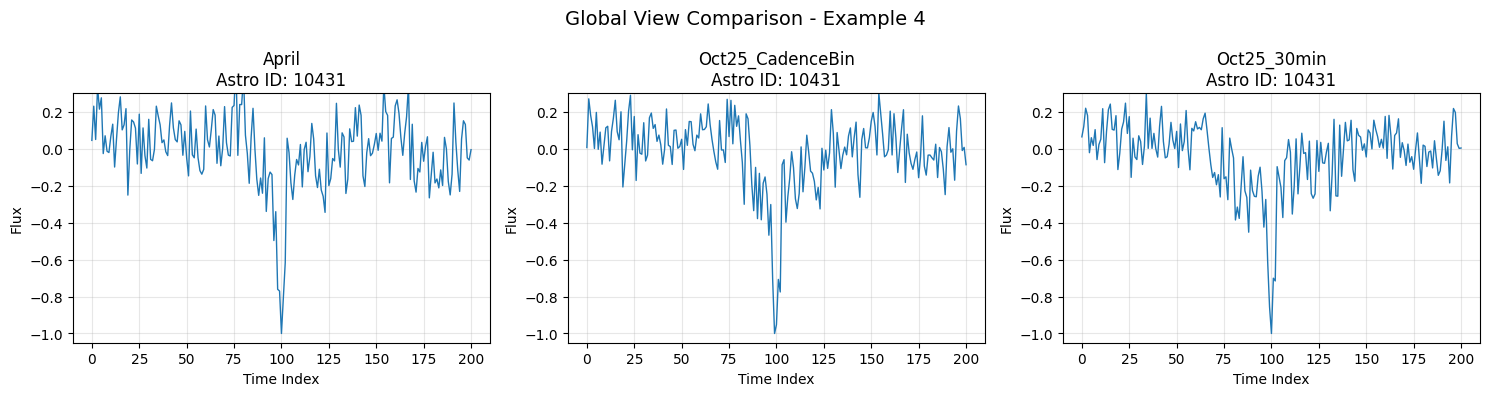


Plotting example 5...


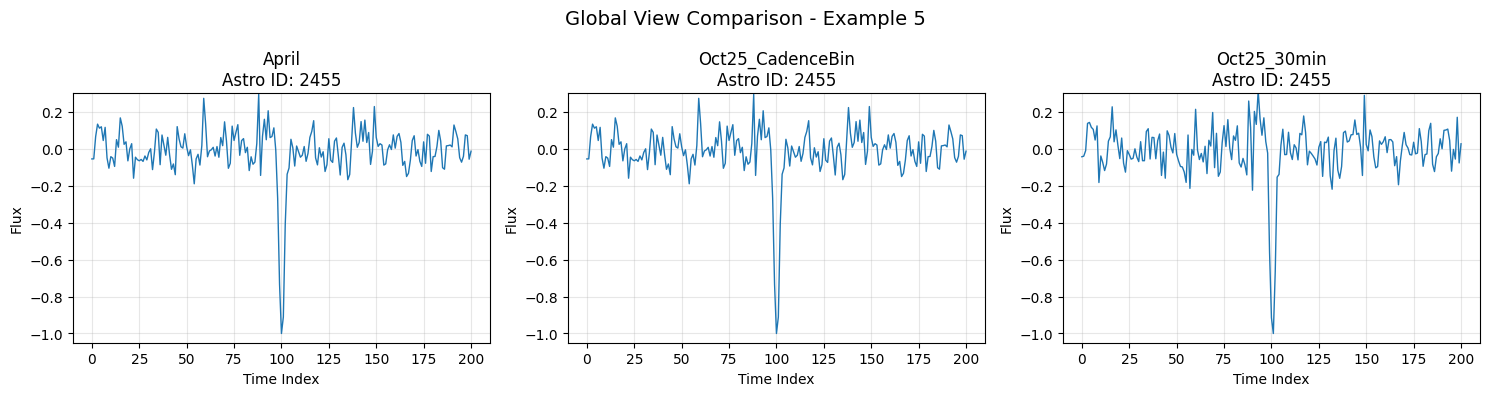


Plotting example 6...


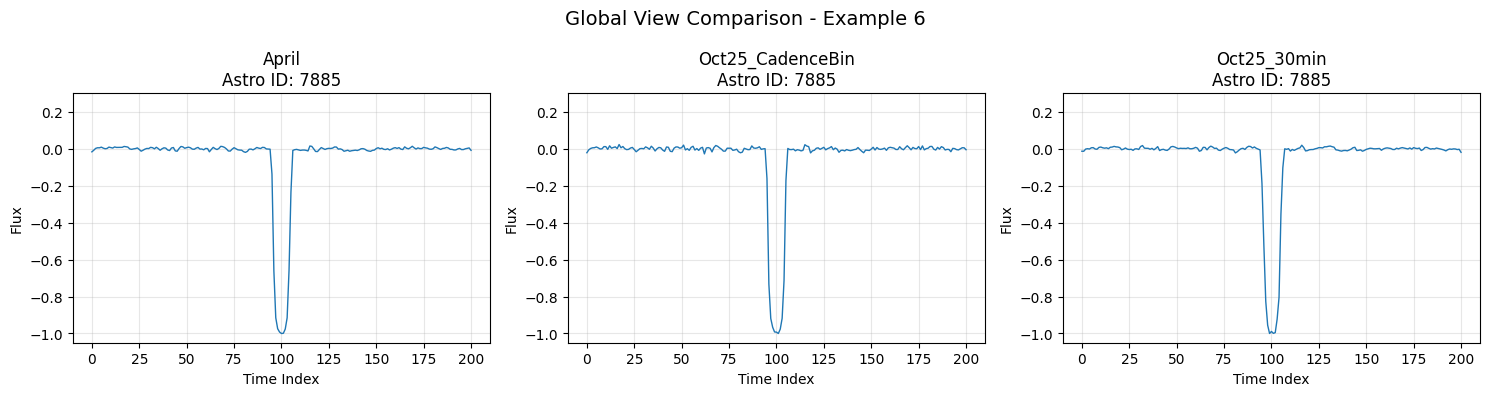


Plotting example 7...


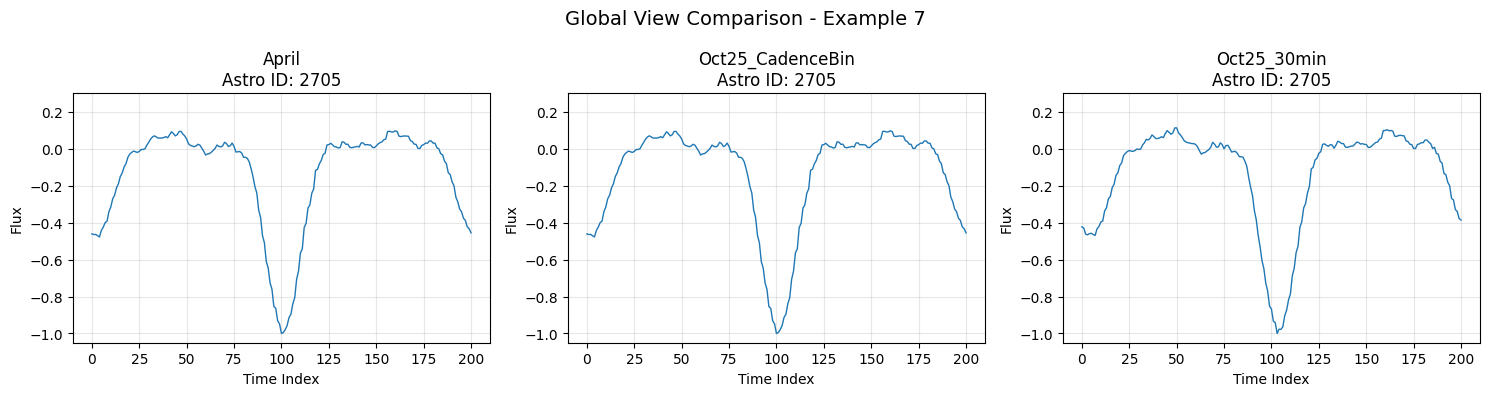


Plotting example 8...


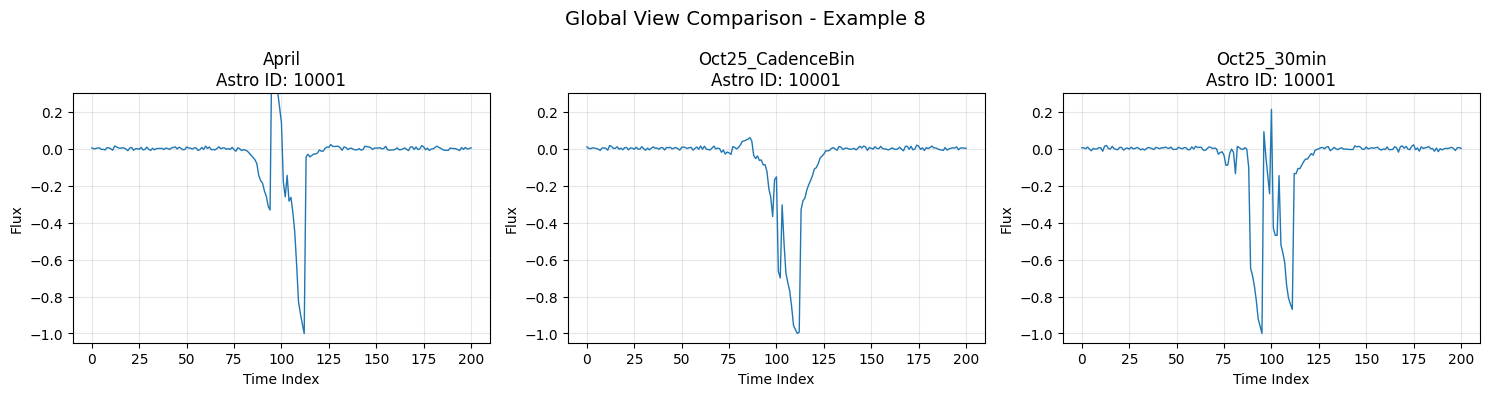


Plotting example 9...


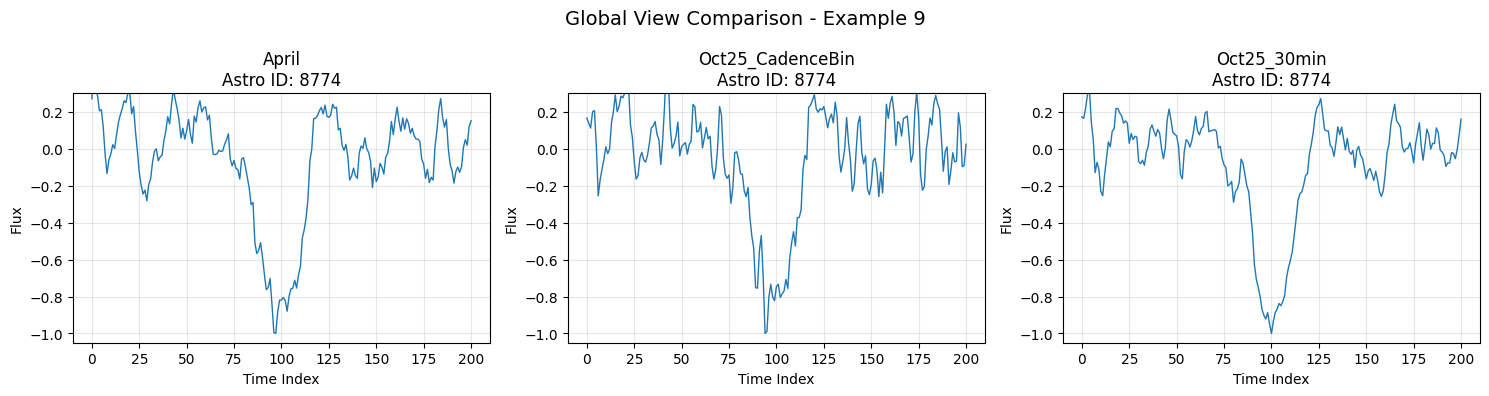


Plotting example 10...


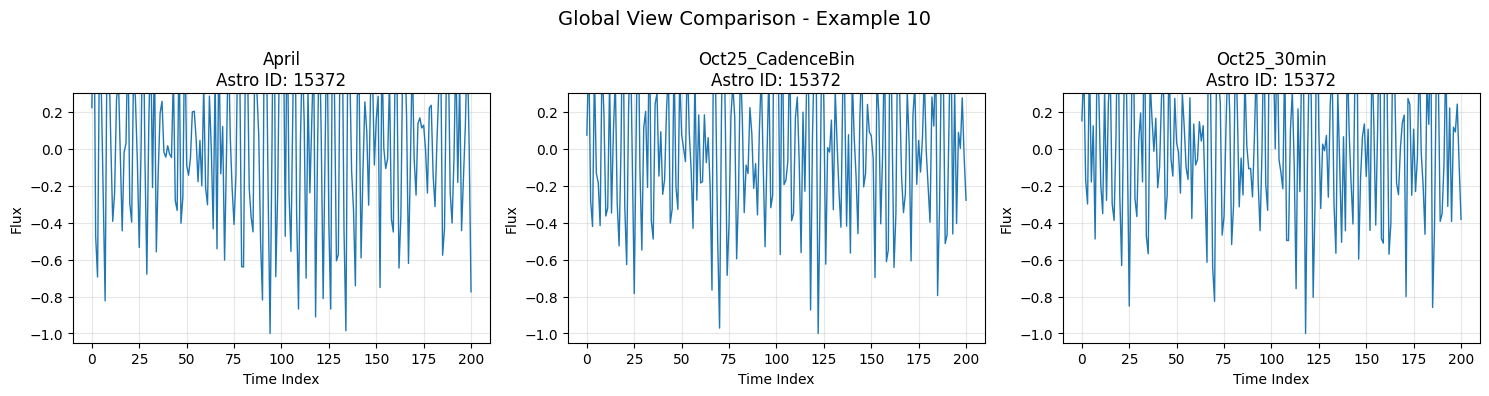


Plotting example 11...


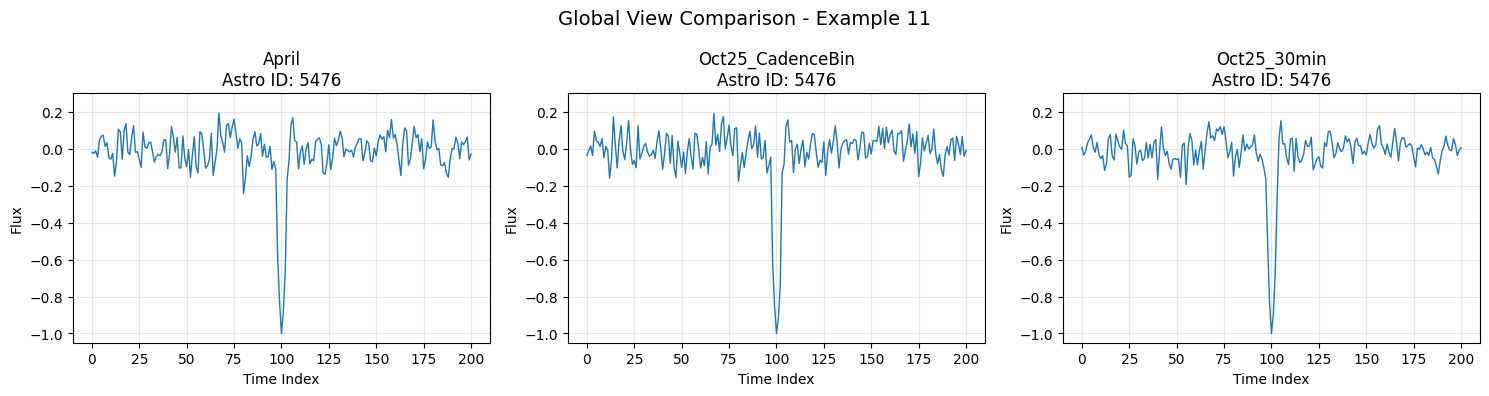


Plotting example 12...


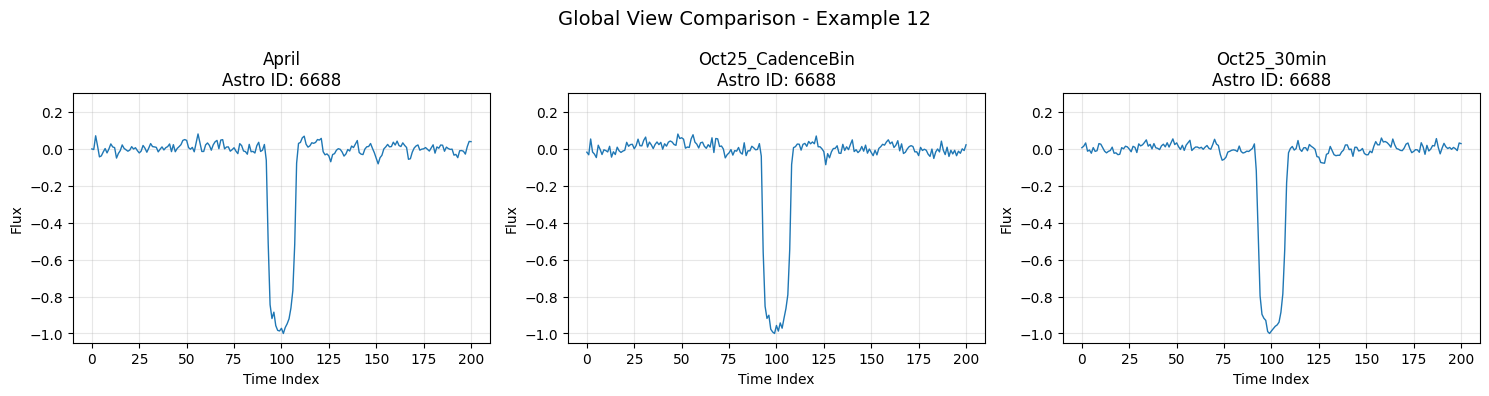


Plotting example 13...


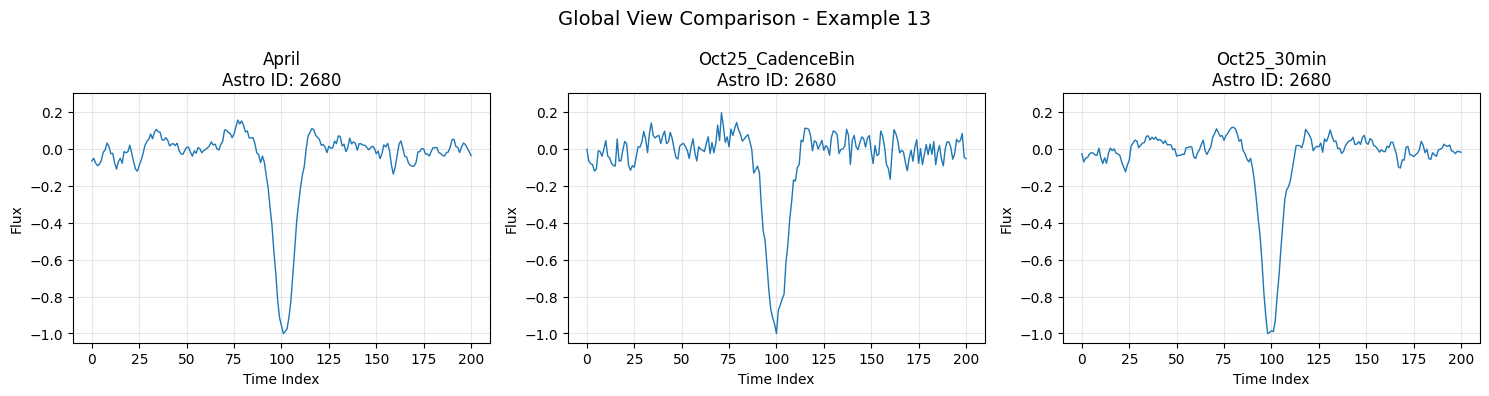


Plotting example 14...


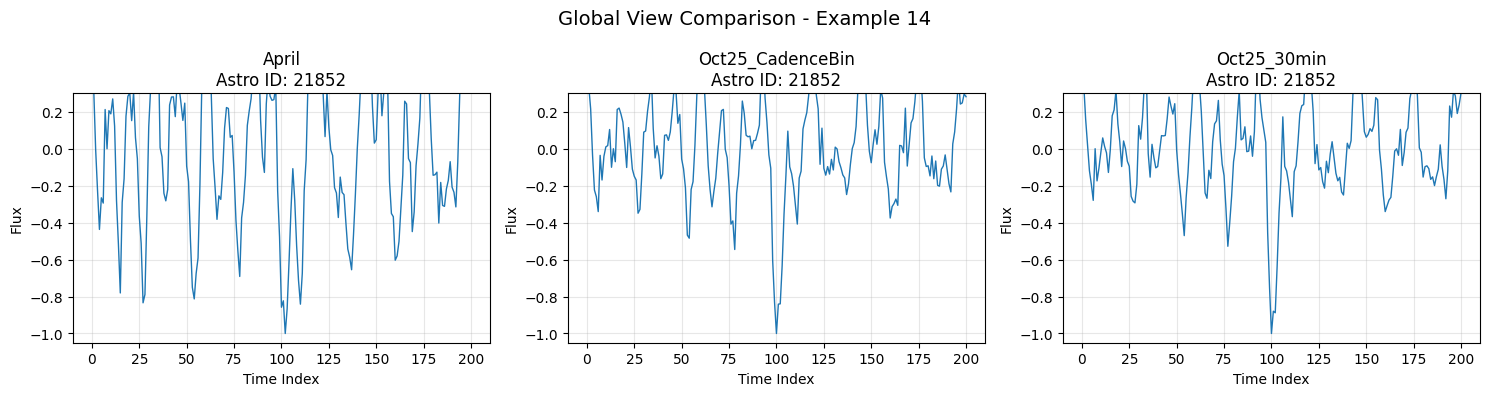


Plotting example 15...


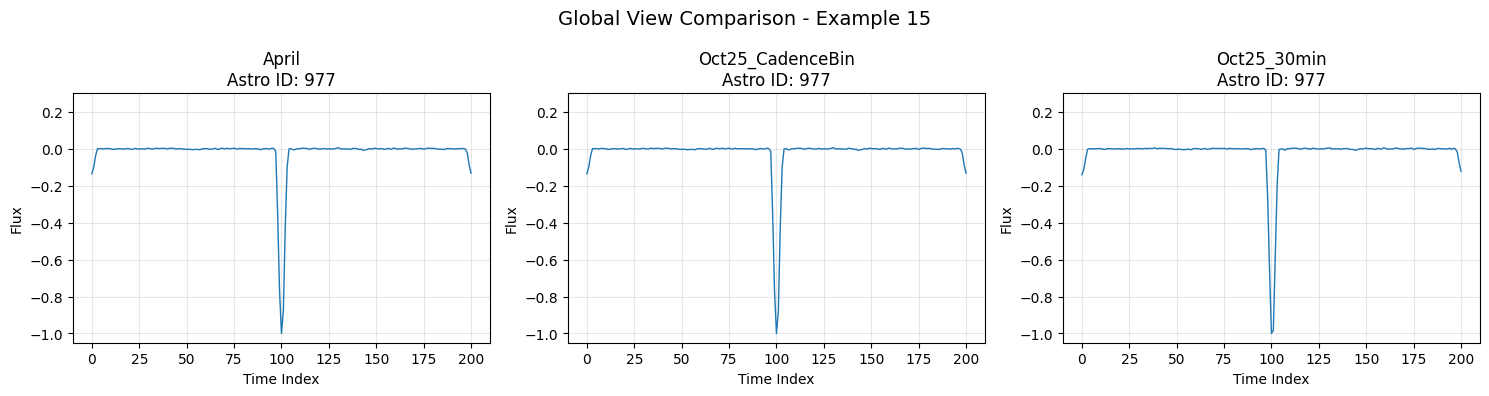


Plotting example 16...


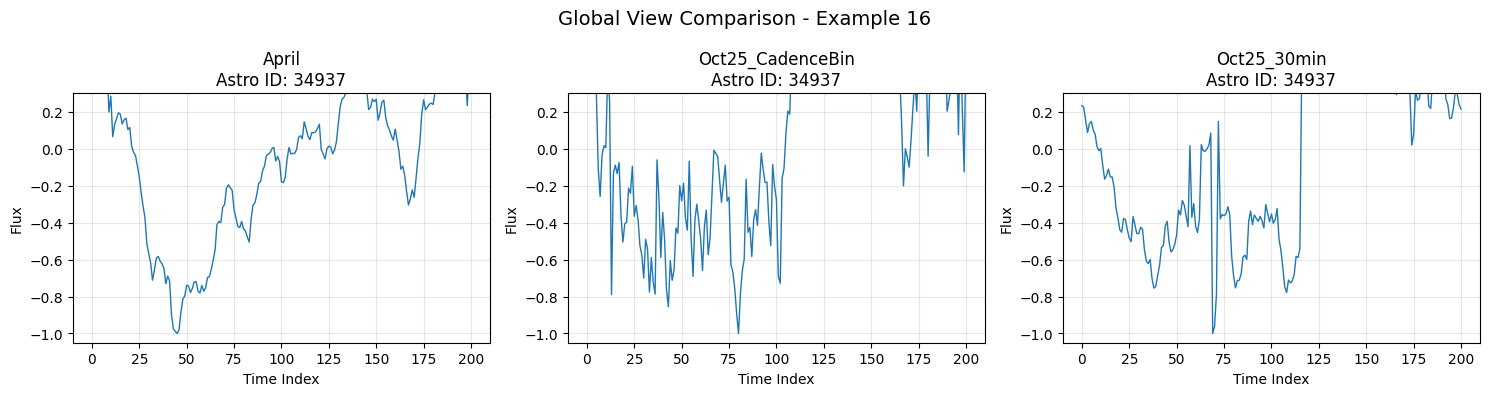


Plotting example 17...


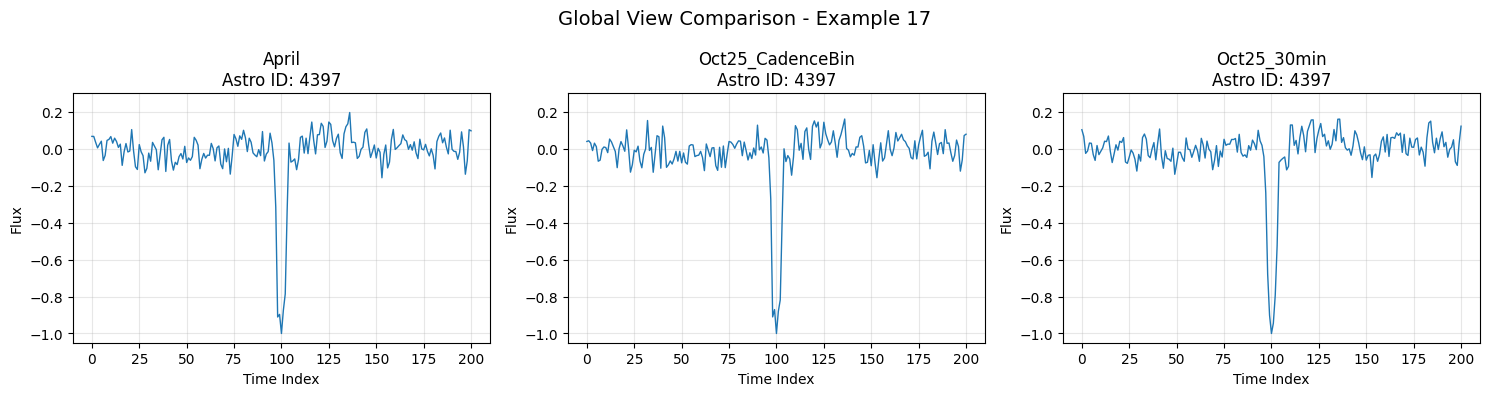


Plotting example 18...


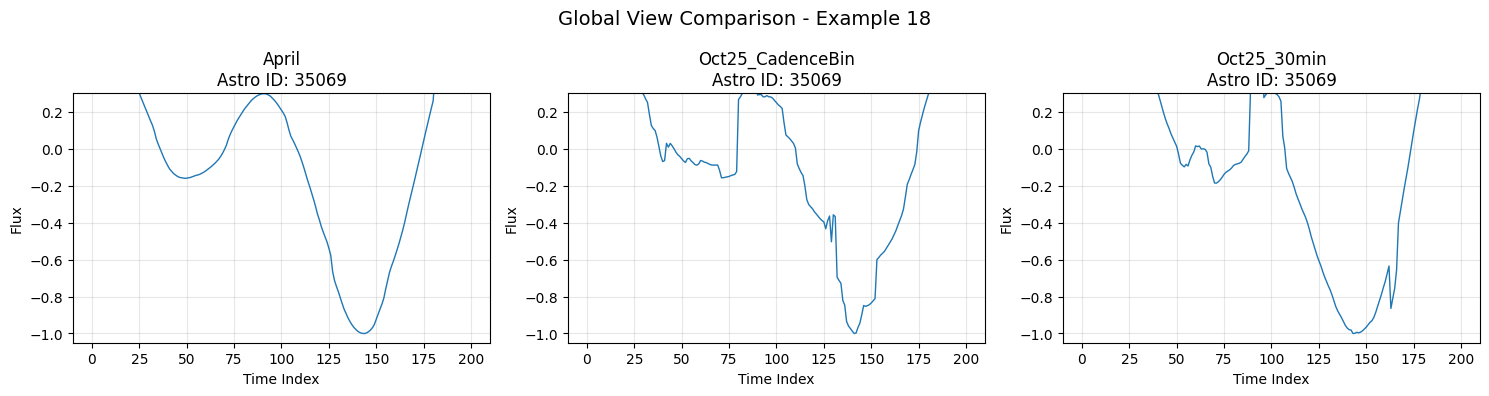


Plotting example 19...


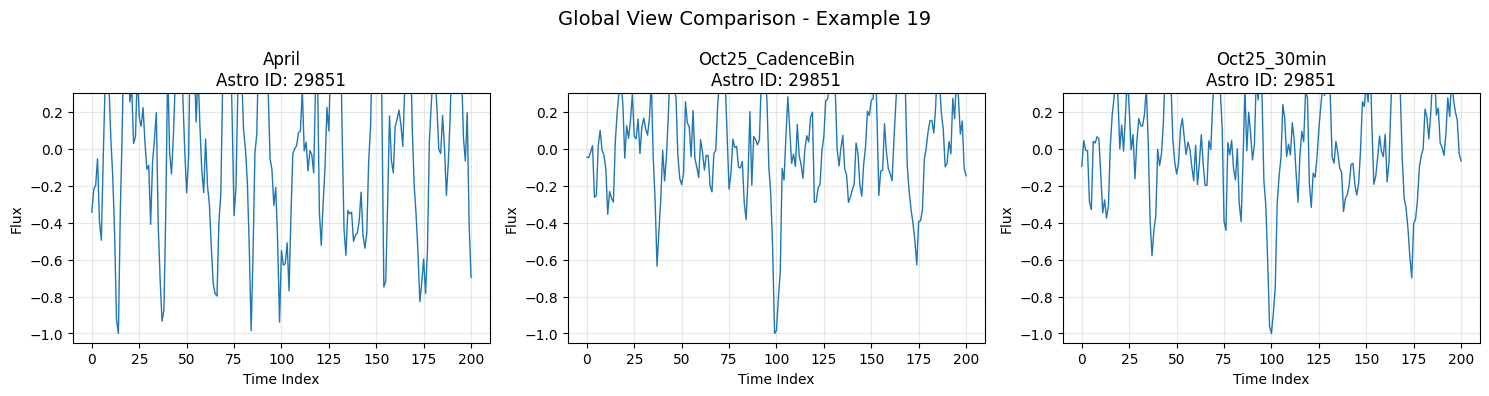


Plotting example 20...


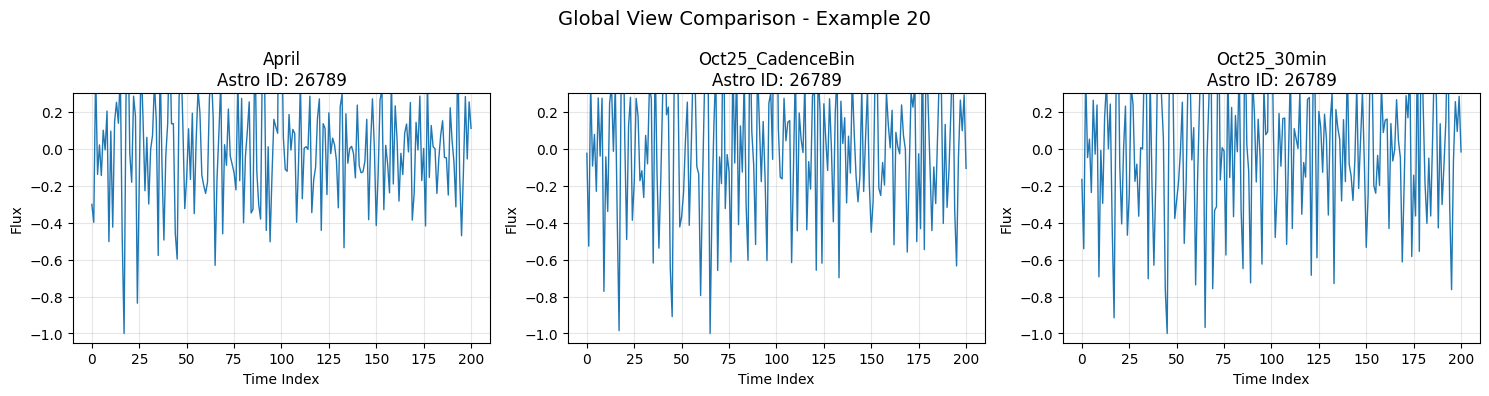

In [26]:
# Generate comparison plots for all 10 examples
print("Generating comparison plots for all examples...")

for example_idx in range(20):
    print(f"\nPlotting example {example_idx + 1}...")
    plot_global_view_comparison(example_idx)


Function defined to plot global view differences
Generating difference plots for all examples...

Plotting differences for example 1...


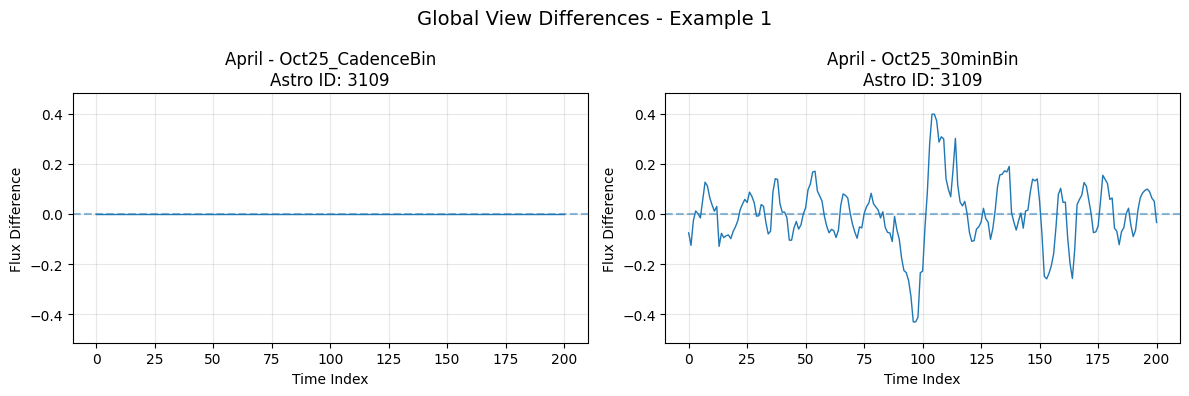


Plotting differences for example 2...


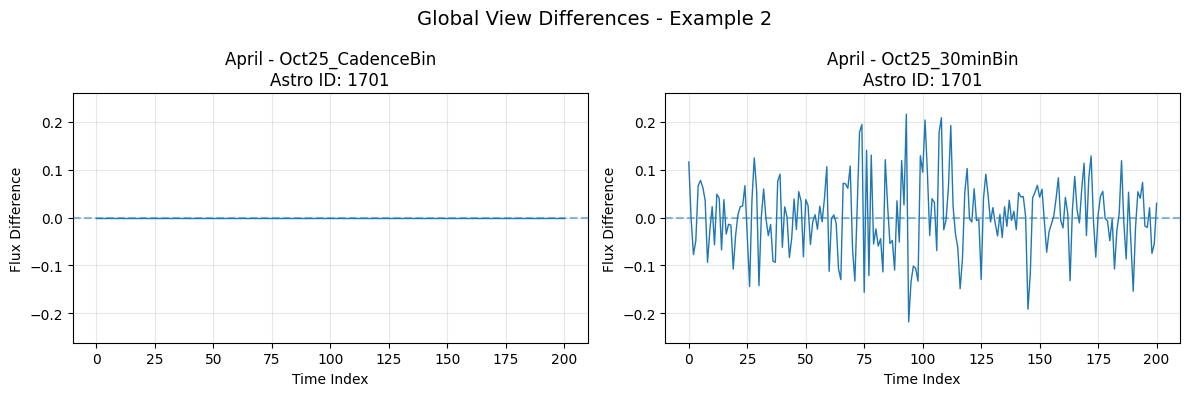


Plotting differences for example 3...


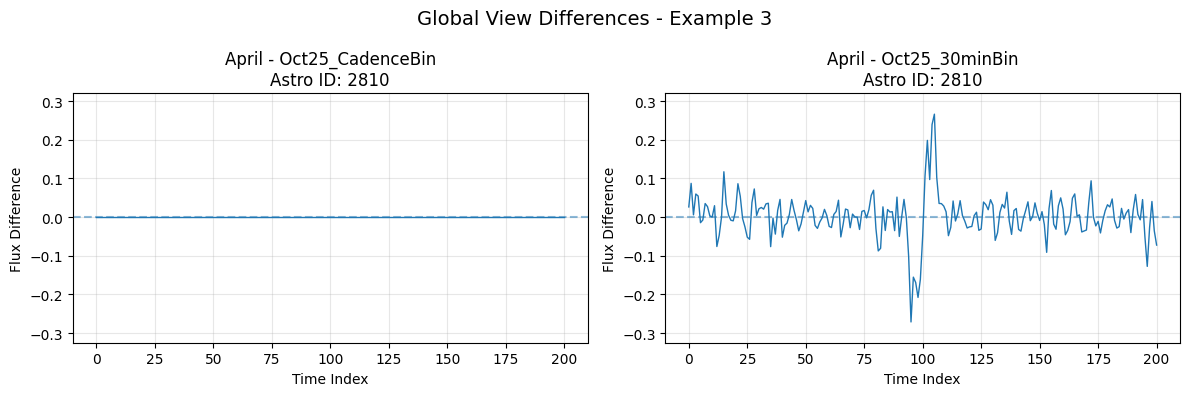


Plotting differences for example 4...


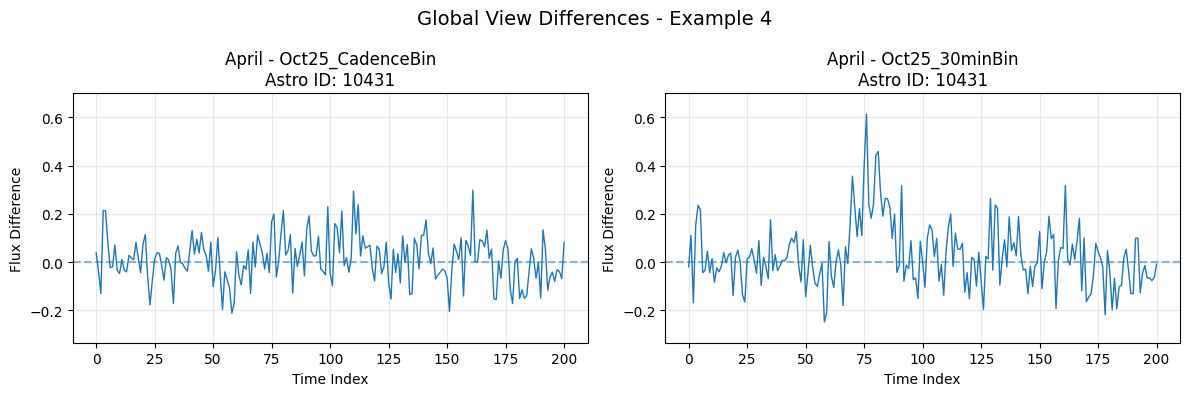


Plotting differences for example 5...


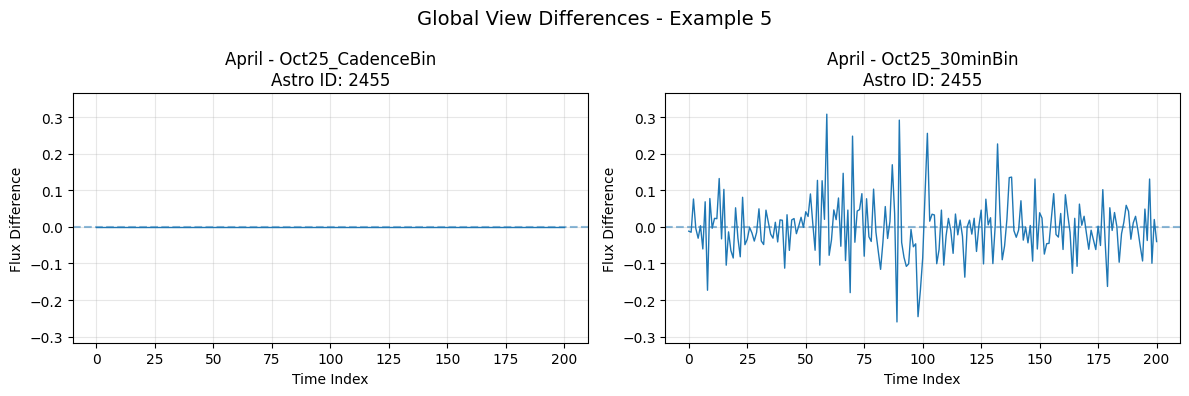


Plotting differences for example 6...


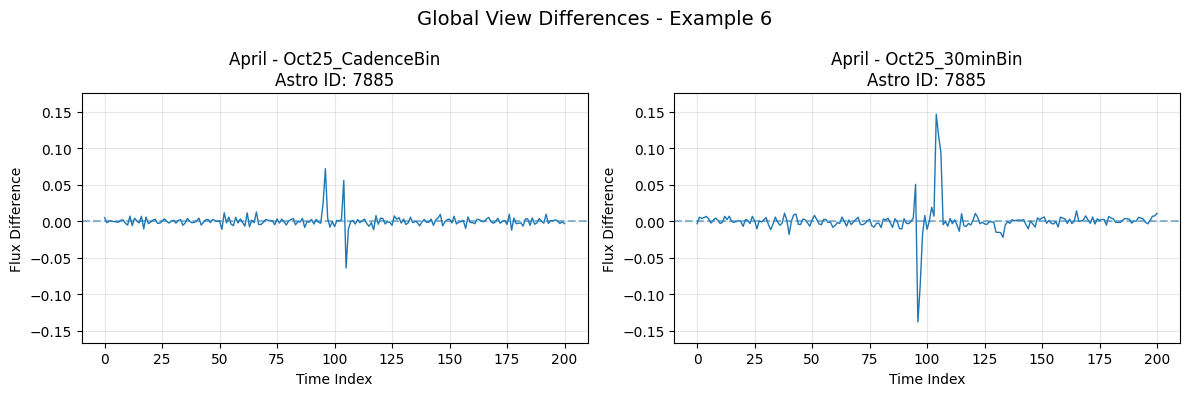


Plotting differences for example 7...


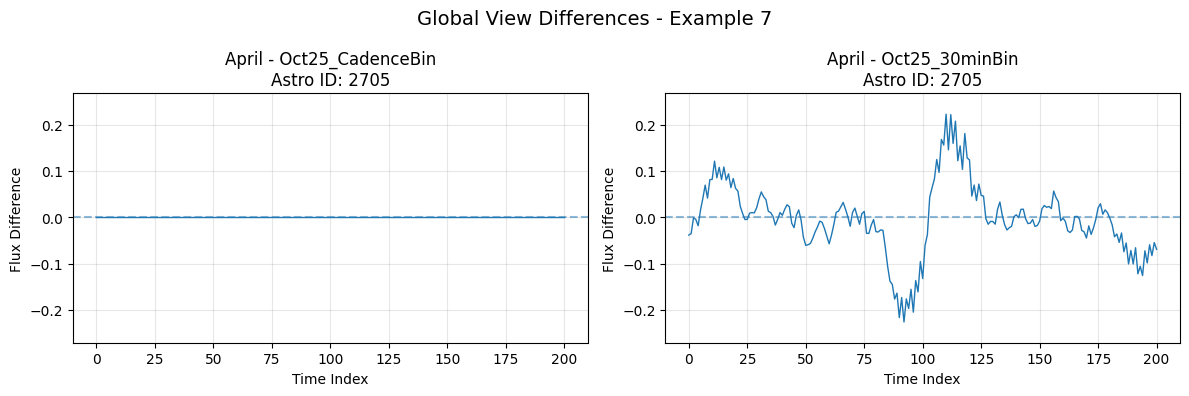


Plotting differences for example 8...


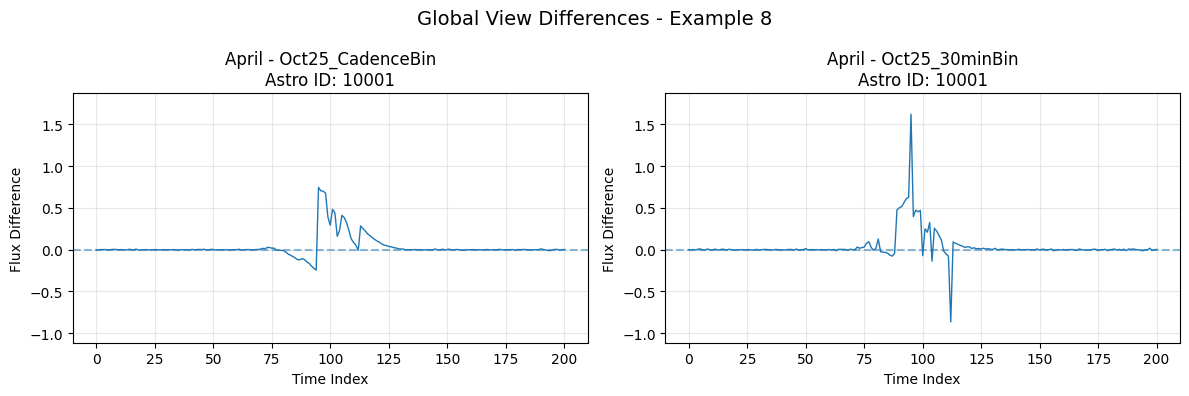


Plotting differences for example 9...


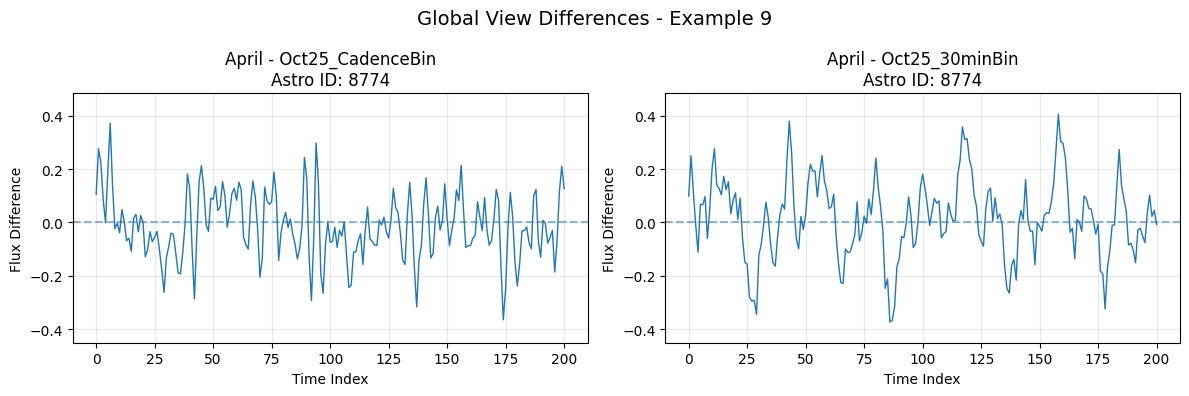


Plotting differences for example 10...


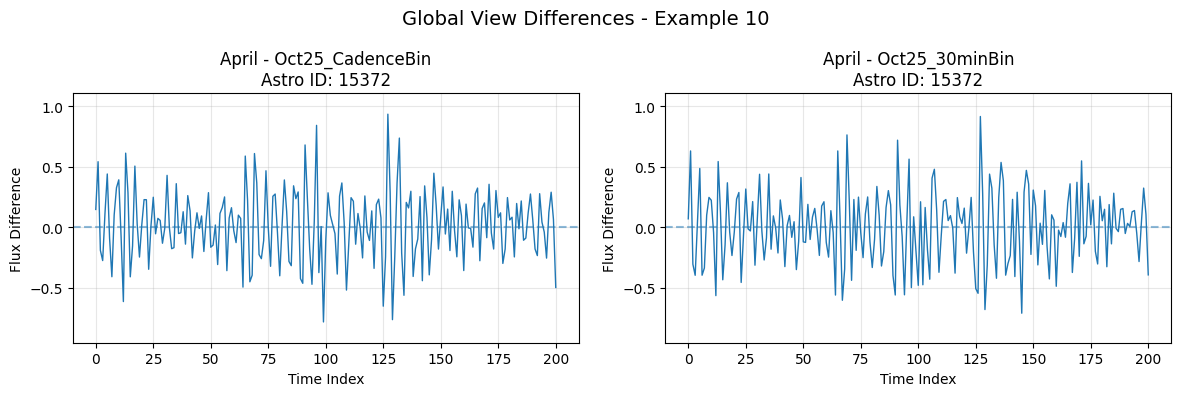


Plotting differences for example 11...


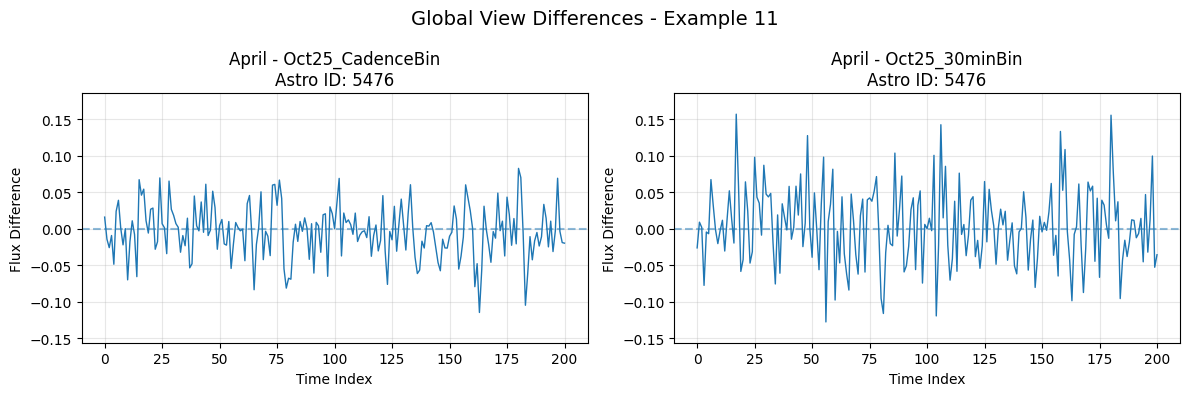


Plotting differences for example 12...


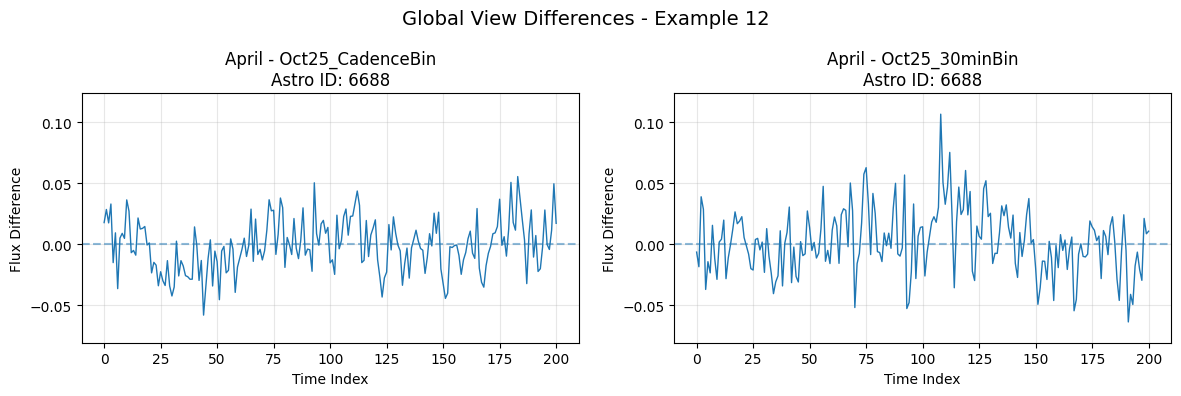


Plotting differences for example 13...


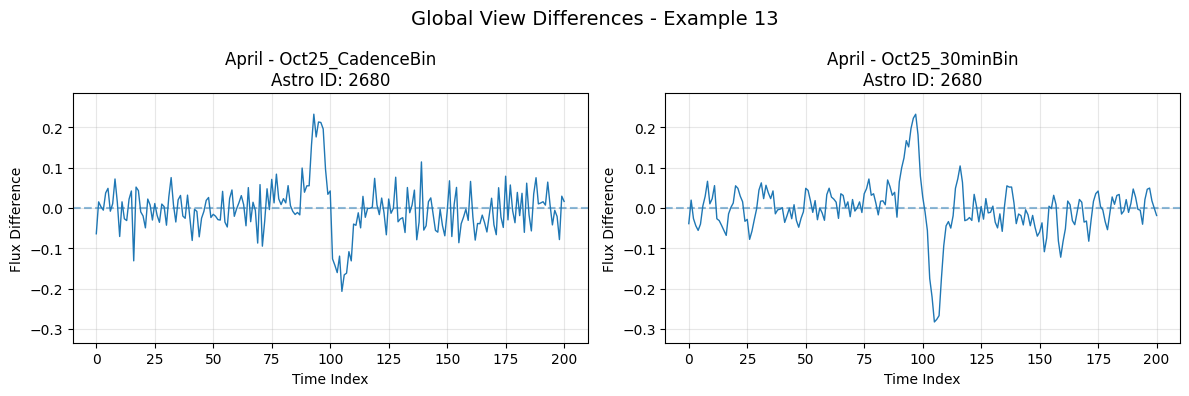


Plotting differences for example 14...


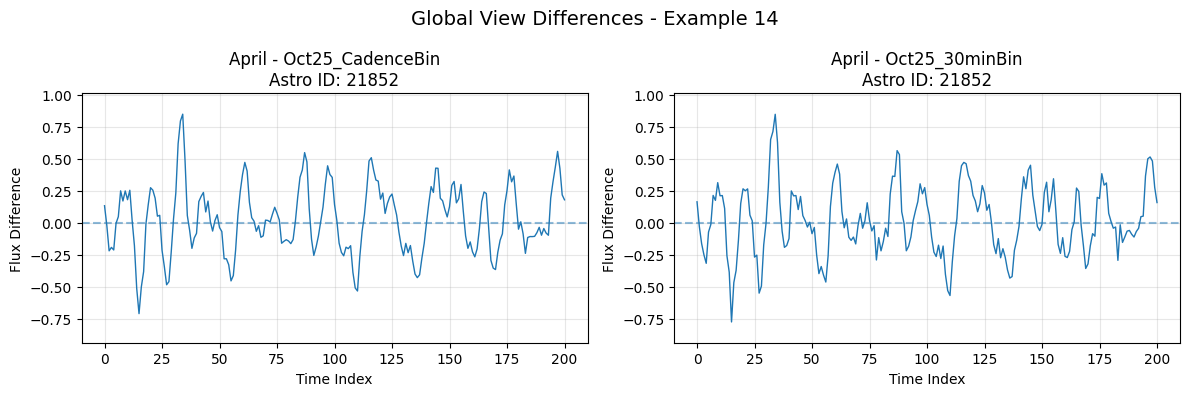


Plotting differences for example 15...


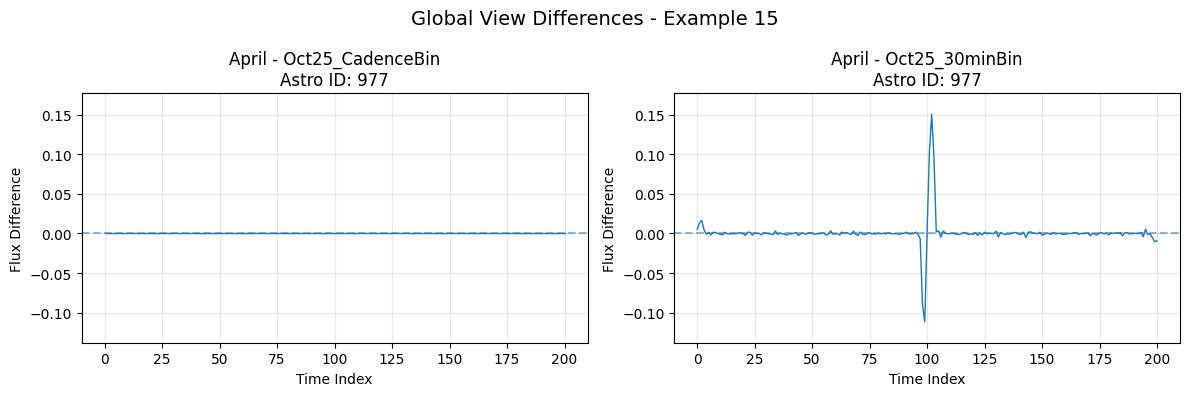


Plotting differences for example 16...


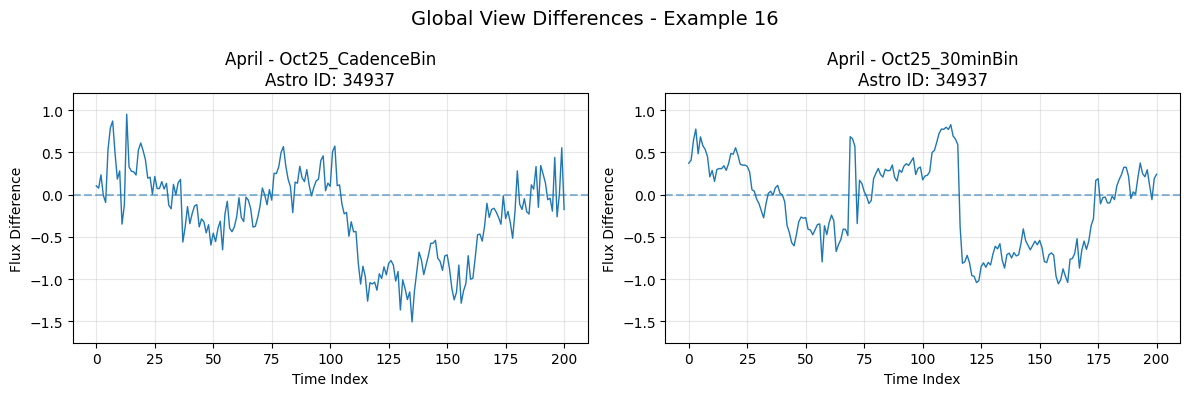


Plotting differences for example 17...


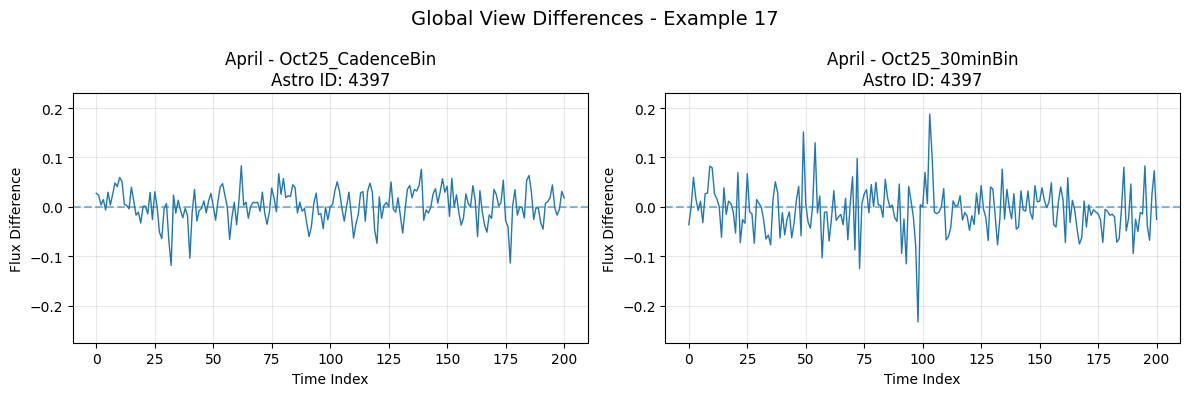


Plotting differences for example 18...


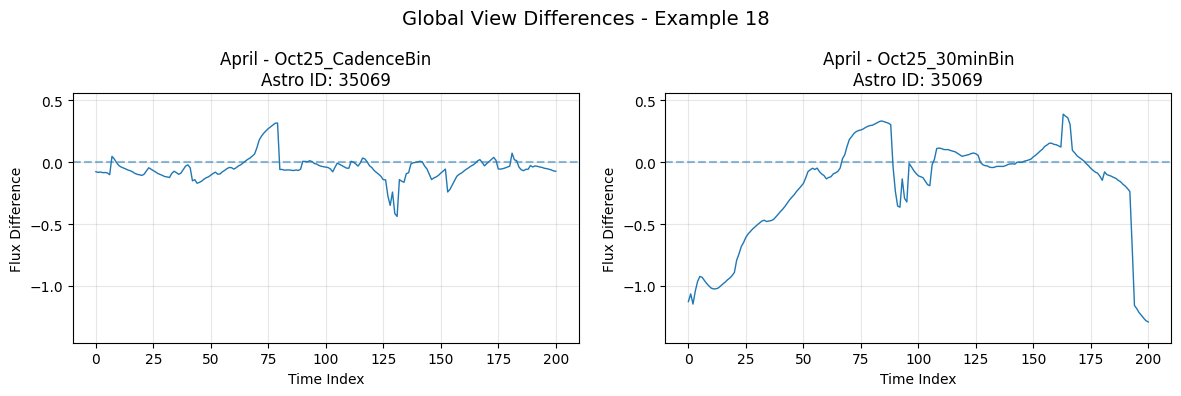


Plotting differences for example 19...


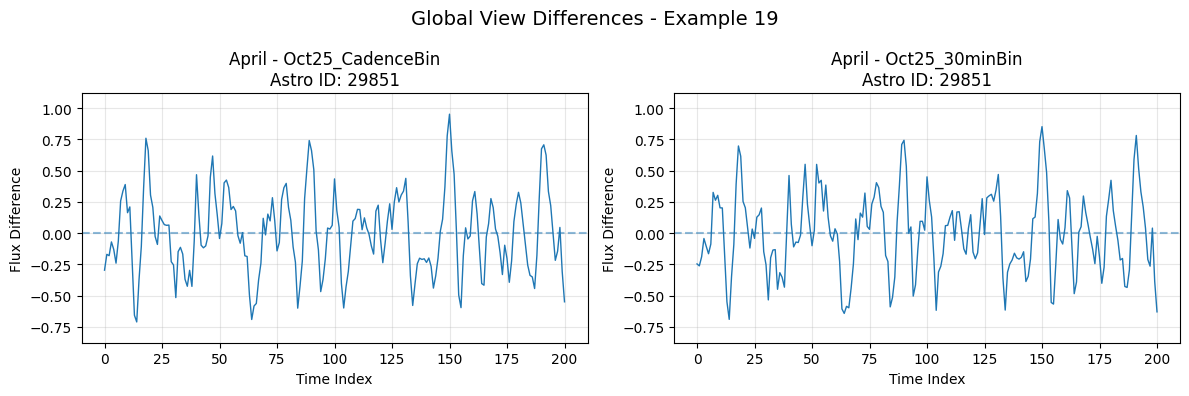


Plotting differences for example 20...


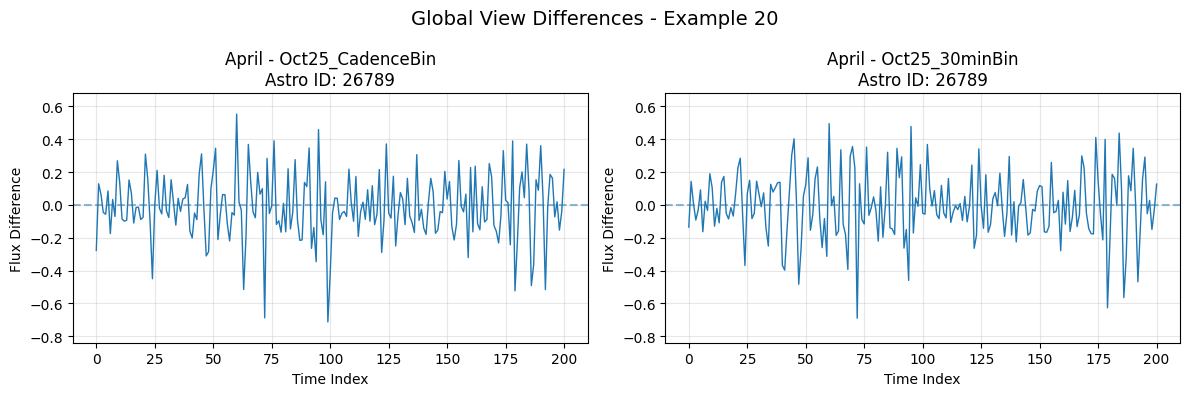

In [28]:
def _safe_get(lst, i, default=None):
    return lst[i] if (i is not None and 0 <= i < len(lst)) else default

def _astro_id_str(example_idx):
    """Format astro_id(s) for the title. If all three match, show one; else show all."""
    aid0 = _safe_get(all_astro_ids[0], example_idx, "N/A")
    aid1 = _safe_get(all_astro_ids[1], example_idx, "N/A")
    aid2 = _safe_get(all_astro_ids[2], example_idx, "N/A")
    if aid0 == aid1 == aid2:
        return f"Astro ID: {aid0}"
    return f"Astro IDs:\nApril={aid0}\nCadenceBin={aid1}\n30minBin={aid2}"

def plot_global_view_differences(example_idx):
    """
    Plot differences between global views from different datasets for a specific example.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    have_all = (
        example_idx < len(all_global_views[0]) and all_global_views[0][example_idx] is not None and
        example_idx < len(all_global_views[1]) and all_global_views[1][example_idx] is not None and
        example_idx < len(all_global_views[2]) and all_global_views[2][example_idx] is not None
    )

    if have_all:
        april_view = all_global_views[0][example_idx]
        oct25_cadencebin_view = all_global_views[1][example_idx]
        oct25_30min_view     = all_global_views[2][example_idx]

        # Differences
        diff1 = april_view - oct25_cadencebin_view
        diff2 = april_view - oct25_30min_view

        axes[0].plot(diff1, linewidth=1)
        axes[0].set_title(f'April - Oct25_CadenceBin\n{_astro_id_str(example_idx)}')
        axes[0].set_xlabel('Time Index')
        axes[0].set_ylabel('Flux Difference')
        axes[0].grid(True, alpha=0.3)
        axes[0].axhline(y=0, linestyle='--', alpha=0.5)

        axes[1].plot(diff2, linewidth=1)
        axes[1].set_title(f'April - Oct25_30minBin\n{_astro_id_str(example_idx)}')
        axes[1].set_xlabel('Time Index')
        axes[1].set_ylabel('Flux Difference')
        axes[1].grid(True, alpha=0.3)
        axes[1].axhline(y=0, linestyle='--', alpha=0.5)

        # Consistent y-lims
        all_diffs = np.concatenate([diff1, diff2])
        y_min, y_max = np.nanmin(all_diffs), np.nanmax(all_diffs)
        pad = (y_max - y_min) * 0.1 if np.isfinite(y_max - y_min) else 0.1
        for ax in axes:
            ax.set_ylim(y_min - pad, y_max + pad)
    else:
        for i, label in enumerate(['April - Oct25_CadenceBin', 'April - Oct25_30minBin']):
            axes[i].text(0.5, 0.5, f'No data available\nfor example {example_idx}',
                         ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{label} - No Data')

    plt.suptitle(f'Global View Differences - Example {example_idx + 1}', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Function defined to plot global view differences")

# ---- Generate difference plots for all available (up to 20) examples ----
print("Generating difference plots for all examples...")

# Safely choose how many to plot: up to 20, bounded by what we actually loaded.
max_available = min(
    20,
    *(len(vs) for vs in all_global_views) if all_global_views else [0]
)

for example_idx in range(max_available):
    print(f"\nPlotting differences for example {example_idx + 1}...")
    plot_global_view_differences(example_idx)

## Summary

This notebook has loaded the first 10 examples from each of the three TFRecord files and generated two types of comparison plots:

### 1. Global View Comparisons
Each plot shows the global views side by side from all three datasets:
- **April dataset**: Global view from the April TFRecord file
- **Oct25 dataset**: Global view from the October 25 TFRecord file  
- **Oct25_CadenceBin dataset**: Global view from the October 25 CadenceBin TFRecord file

### 2. Difference Plots
Each difference plot shows the flux differences between datasets:
- **Left plot**: April - Oct25 (shows how April differs from Oct25)
- **Right plot**: Oct25 - Oct25_CadenceBin (shows how Oct25 differs from Oct25_CadenceBin)

The difference plots include:
- A red dashed line at y=0 for reference
- Consistent y-axis scaling to compare the magnitude of differences
- Grid lines for easier reading

These plots allow you to visually compare how the global views differ between the different datasets and quantify the differences between them.


## Summary

This notebook has loaded the first 10 examples from each of the three TFRecord files and generated comparison plots showing the global views side by side. Each plot shows:

1. **April dataset**: Global view from the April TFRecord file
2. **Oct25 dataset**: Global view from the October 25 TFRecord file  
3. **Oct25_CadenceBin dataset**: Global view from the October 25 CadenceBin TFRecord file

The plots allow you to visually compare how the global views differ between the different datasets for the same examples.
